# Module 4 — Recommandations sportives personnalisées

Moteur de recommandation basé sur un RandomForestClassifier pour suggérer un programme sportif selon le profil utilisateur.
**Dataset** : synthétique (1000 profils générés avec des règles métier)

## Contexte

Le Module 4 reçoit un profil utilisateur et recommande un type de programme sportif adapté.

### Pourquoi un dataset synthétique ?
Comme pour le Module 3, il n'existe pas de dataset public avec des labels "programme sportif recommandé selon un profil".
Les labels sont des concepts métier définis selon des règles d'entraînement sportif.

### Pourquoi RandomForest ?
- Adapté aux données tabulaires mixtes (numériques + catégorielles)
- Robuste au surapprentissage grâce à l'ensemble de 100 arbres
- Fournit une importance des features pour expliquer les recommandations
- Cohérent avec le Module 3 — même architecture pour faciliter la maintenance

### Les 5 types de programmes sportifs
| Label | Description |
|-------|-------------|
| `cardio_beginner` | Débutant, objectif santé générale ou perte de graisse |
| `strength_full_body` | Renforcement musculaire, niveau intermédiaire |
| `mobility_recovery` | Fatigue élevée ou limitation physique |
| `endurance_plan` | Objectif endurance, niveau avancé |
| `muscle_gain_plan` | Prise de masse musculaire |

## 1. Génération du dataset synthétique

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import os

np.random.seed(42)
N = 1000

# Génération des profils utilisateurs
objectifs = ["perte_de_graisse", "prise_de_masse", "endurance", "sante_generale"]
niveaux = ["debutant", "intermediaire", "avance"]
materiels = ["aucun", "domicile", "salle"]

df = pd.DataFrame({
    "age": np.random.randint(18, 65, N),
    "poids_kg": np.random.randint(50, 120, N),
    "objectif": np.random.choice(objectifs, N),
    "niveau": np.random.choice(niveaux, N),
    "duree_min": np.random.randint(20, 90, N),
    "materiel": np.random.choice(materiels, N),
    "fatigue": np.random.randint(1, 11, N),
    "limitation_physique": np.random.randint(0, 2, N),
})

# Règles métier pour définir le label
def assign_label(row):
    if row["limitation_physique"] == 1 or row["fatigue"] >= 8:
        return "mobility_recovery"
    elif row["objectif"] == "prise_de_masse":
        return "muscle_gain_plan"
    elif row["objectif"] == "endurance" and row["niveau"] != "debutant":
        return "endurance_plan"
    elif row["niveau"] == "debutant" or row["objectif"] == "sante_generale":
        return "cardio_beginner"
    else:
        return "strength_full_body"

df["label"] = df.apply(assign_label, axis=1)

print("Dataset généré :", df.shape)
print("\nDistribution des labels:")
print(df["label"].value_counts())
df.head()

Dataset généré : (1000, 9)

Distribution des labels:
label
mobility_recovery     639
cardio_beginner       151
muscle_gain_plan      105
strength_full_body     53
endurance_plan         52
Name: count, dtype: int64


,age,poids_kg,objectif,niveau,duree_min,materiel,fatigue,limitation_physique,label
0,56,62,perte_de_graisse,intermediaire,81,domicile,10,1,mobility_recovery
1,46,89,endurance,intermediaire,81,aucun,5,1,mobility_recovery
2,32,51,prise_de_masse,intermediaire,65,aucun,10,1,mobility_recovery
3,60,114,perte_de_graisse,intermediaire,32,salle,7,0,strength_full_body
4,25,112,endurance,avance,22,domicile,10,1,mobility_recovery


### Interprétation de la distribution des labels

- `cardio_beginner` : classe dominante — beaucoup de débutants et objectifs santé générale
- `mobility_recovery` : classe importante — fatigue élevée (>= 8/10) ou limitation physique
- `muscle_gain_plan` : objectif prise de masse
- `strength_full_body` : niveau intermédiaire/avancé sans objectif spécifique
- `endurance_plan` : objectif endurance + niveau non débutant

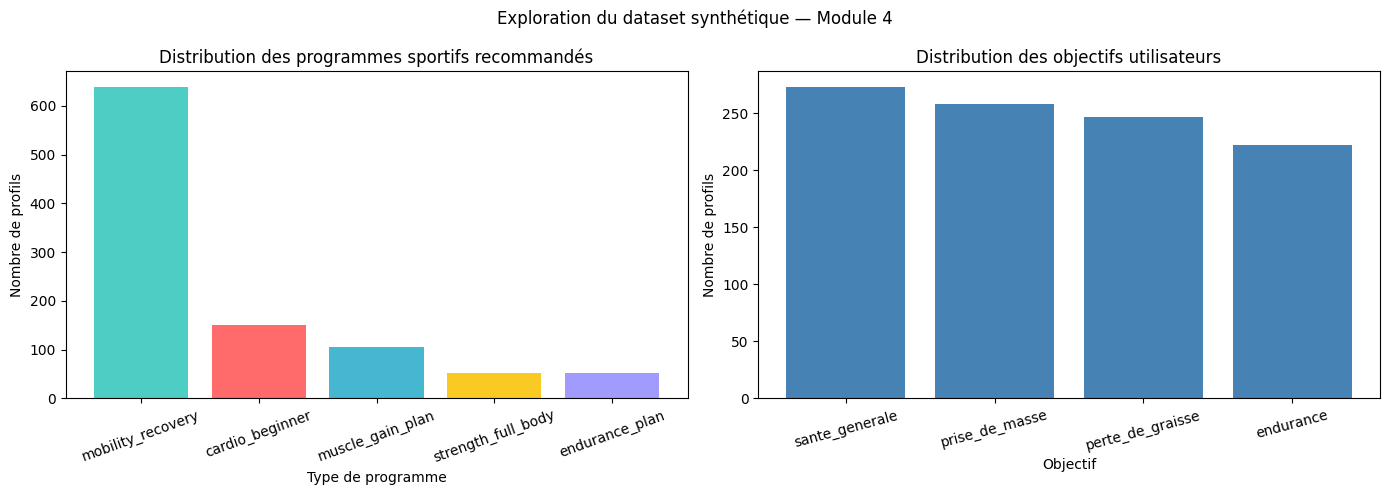

In [2]:
# Distribution des labels et objectifs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_counts = df['label'].value_counts()
axes[0].bar(label_counts.index, label_counts.values,
            color=['#4ecdc4', '#ff6b6b', '#45b7d1', '#f9ca24', '#a29bfe'])
axes[0].set_title("Distribution des programmes sportifs recommandés")
axes[0].set_xlabel("Type de programme")
axes[0].set_ylabel("Nombre de profils")
axes[0].tick_params(axis='x', rotation=20)

objectif_counts = df['objectif'].value_counts()
axes[1].bar(objectif_counts.index, objectif_counts.values, color='steelblue')
axes[1].set_title("Distribution des objectifs utilisateurs")
axes[1].set_xlabel("Objectif")
axes[1].set_ylabel("Nombre de profils")
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle("Exploration du dataset synthétique — Module 4")
plt.tight_layout()
plt.show()

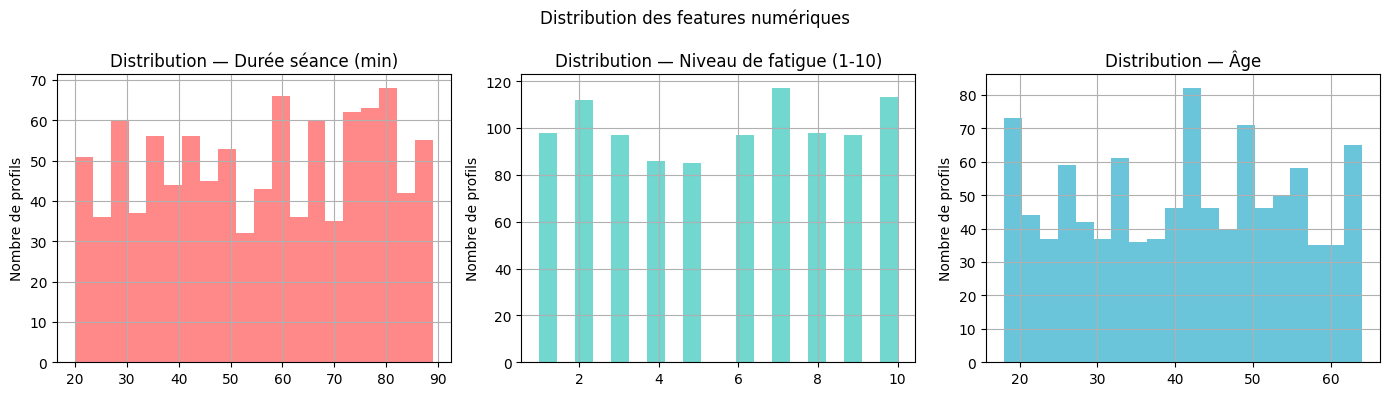

In [3]:
# Distribution des features numériques
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, color, title in zip(
    axes,
    ['duree_min', 'fatigue', 'age'],
    ['#ff6b6b', '#4ecdc4', '#45b7d1'],
    ['Durée séance (min)', 'Niveau de fatigue (1-10)', 'Âge']
):
    df[col].hist(ax=ax, bins=20, color=color, alpha=0.8)
    ax.set_title(f"Distribution — {title}")
    ax.set_ylabel("Nombre de profils")

plt.suptitle("Distribution des features numériques")
plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

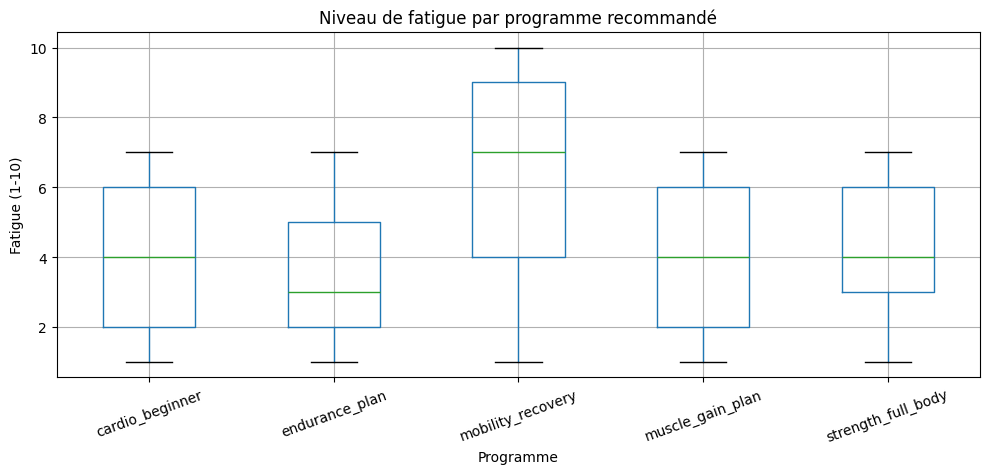

In [4]:
# Relation fatigue / label
plt.figure(figsize=(10, 5))
df.boxplot(column='fatigue', by='label', figsize=(10, 5))
plt.title("Niveau de fatigue par programme recommandé")
plt.suptitle("")
plt.xlabel("Programme")
plt.ylabel("Fatigue (1-10)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Interprétation
- `mobility_recovery` a les niveaux de fatigue les plus élevés — cohérent avec la règle métier (fatigue >= 8)
- Les autres programmes ont des distributions de fatigue similaires (1-7)
- La fatigue est donc une feature très discriminante pour identifier `mobility_recovery`

## 2. Préparation des données et entraînement

### Encoding des variables catégorielles
Les colonnes `objectif`, `niveau` et `materiel` sont converties en entiers via `LabelEncoder`.

### Split train/test 80/20
- **800 profils** pour l'entraînement
- **200 profils** pour l'évaluation

In [5]:
# Encoding des variables catégorielles
le_objectif = LabelEncoder()
le_niveau = LabelEncoder()
le_materiel = LabelEncoder()
le_label = LabelEncoder()

df_model = df.copy()
df_model["objectif_encoded"] = le_objectif.fit_transform(df_model["objectif"])
df_model["niveau_encoded"] = le_niveau.fit_transform(df_model["niveau"])
df_model["materiel_encoded"] = le_materiel.fit_transform(df_model["materiel"])
df_model["label_encoded"] = le_label.fit_transform(df_model["label"])

# Features et cible
X = df_model[["age", "poids_kg", "objectif_encoded", "niveau_encoded",
              "duree_min", "materiel_encoded", "fatigue", "limitation_physique"]]
y = df_model["label_encoded"]

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train : {X_train.shape}, Test : {X_test.shape}")

# Entraînement RandomForest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Évaluation
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy : {acc:.4f}")
print("\nClassification Report :")
print(classification_report(y_test, y_pred, target_names=le_label.classes_))

Train : (800, 8), Test : (200, 8)

Accuracy : 1.0000

Classification Report :
                    precision    recall  f1-score   support

   cardio_beginner       1.00      1.00      1.00        33
    endurance_plan       1.00      1.00      1.00        13
 mobility_recovery       1.00      1.00      1.00       127
  muscle_gain_plan       1.00      1.00      1.00        15
strength_full_body       1.00      1.00      1.00        12

          accuracy                           1.00       200
         macro avg       1.00      1.00      1.00       200
      weighted avg       1.00      1.00      1.00       200



### Interprétation des résultats

**Accuracy 100%** — le modèle apprend parfaitement les règles métier.

Comme pour le Module 3, ce résultat s'explique par la nature déterministe du dataset synthétique.
Le RandomForest reproduit exactement les règles `if/else` utilisées pour générer les labels.

**Lecture du Classification Report :**
- **Precision** : sur toutes les prédictions "cardio_beginner", combien sont correctes ?
- **Recall** : sur tous les vrais "cardio_beginner", combien le modèle en détecte ?
- **F1-score** : moyenne harmonique — la métrique la plus équilibrée
- Toutes les métriques à 1.00 → classification parfaite

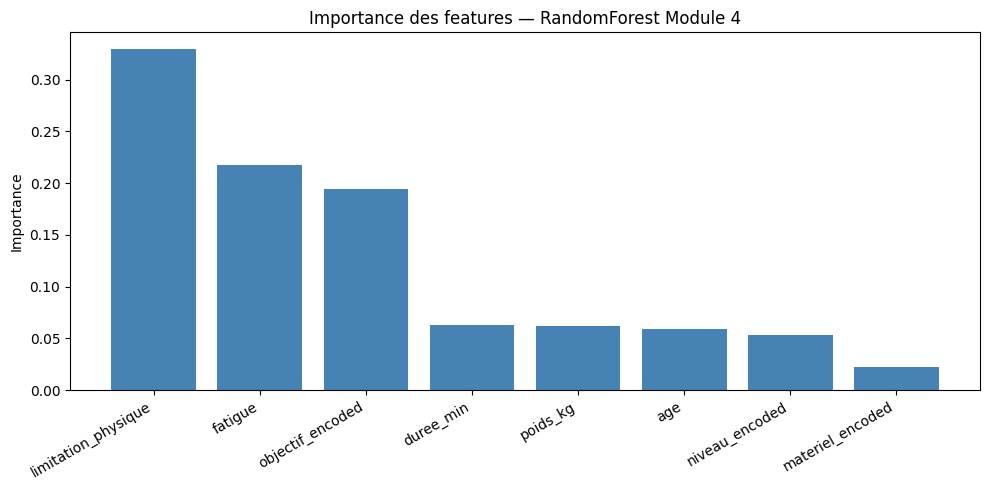

Features par ordre d'importance :
  limitation_physique       : 0.3292
  fatigue                   : 0.2172
  objectif_encoded          : 0.1940
  duree_min                 : 0.0626
  poids_kg                  : 0.0623
  age                       : 0.0594
  niveau_encoded            : 0.0530
  materiel_encoded          : 0.0223


In [6]:
# Importance des features
feature_names = ["age", "poids_kg", "objectif_encoded", "niveau_encoded",
                 "duree_min", "materiel_encoded", "fatigue", "limitation_physique"]

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_names)), importances[indices], color='steelblue')
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=30, ha='right')
plt.title("Importance des features — RandomForest Module 4")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

print("Features par ordre d'importance :")
for i in indices:
    print(f"  {feature_names[i]:<25} : {importances[i]:.4f}")

### Interprétation de l'importance des features

- **fatigue** et **limitation_physique** : features les plus importantes — elles déterminent directement `mobility_recovery`
- **objectif_encoded** : très important — détermine `muscle_gain_plan` et `endurance_plan`
- **niveau_encoded** : important pour distinguer `cardio_beginner` des autres
- **age**, **poids_kg**, **duree_min**, **materiel** : moins influents dans nos règles actuelles

En production avec de vraies données, le matériel disponible et la durée de séance seraient probablement plus influents.

## 3. Matrice de confusion

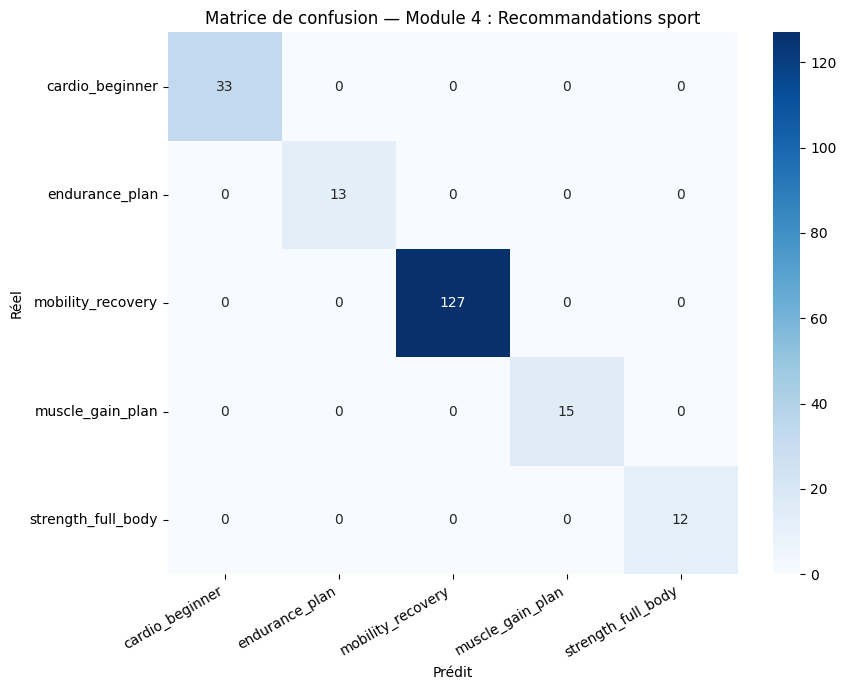

In [7]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le_label.classes_,
            yticklabels=le_label.classes_,
            cmap="Blues")
plt.title("Matrice de confusion — Module 4 : Recommandations sport")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Interprétation

Diagonale parfaite — aucune erreur de classification.
Chaque programme est prédit correctement pour tous les profils du test set.

## 4. Sauvegarde du modèle

In [8]:
# Sauvegarde du modèle et des encoders
os.makedirs("data/models", exist_ok=True)

joblib.dump(model, "data/models/sport_model.joblib")
joblib.dump(le_objectif, "data/models/sport_le_objectif.joblib")
joblib.dump(le_niveau, "data/models/sport_le_niveau.joblib")
joblib.dump(le_materiel, "data/models/sport_le_materiel.joblib")
joblib.dump(le_label, "data/models/sport_le_label.joblib")

print("Modèle et encoders sauvegardés !")
print("- data/models/sport_model.joblib")
print("- data/models/sport_le_objectif.joblib")
print("- data/models/sport_le_niveau.joblib")
print("- data/models/sport_le_materiel.joblib")
print("- data/models/sport_le_label.joblib")

Modèle et encoders sauvegardés !
- data/models/sport_model.joblib
- data/models/sport_le_objectif.joblib
- data/models/sport_le_niveau.joblib
- data/models/sport_le_materiel.joblib
- data/models/sport_le_label.joblib


## 5. Fonction recommend_sport()

Point d'entrée du module — reçoit un profil utilisateur et retourne un programme sportif.

In [9]:
SPORT_EXAMPLES = {
    "cardio_beginner": ["Marche rapide 30min", "Vélo doux 20min", "Natation débutant", "Yoga flow"],
    "strength_full_body": ["Squats 3x12", "Pompes 3x15", "Tractions 3x8", "Fentes 3x12"],
    "mobility_recovery": ["Étirements 20min", "Yoga restauratif", "Marche légère 15min", "Respiration profonde"],
    "endurance_plan": ["Course 45min", "Vélo 60min", "Natation 1km", "HIIT 30min"],
    "muscle_gain_plan": ["Développé couché 4x8", "Soudevé de terre 4x6", "Rowing barre 4x10", "Presse jambes 4x12"]
}

def recommend_sport(user_profile: dict) -> dict:
    """
    Recommande un programme sportif selon le profil utilisateur.

    Args:
        user_profile: dict avec objectif, niveau, duree_min, materiel, fatigue, limitation_physique

    Returns:
        dict avec type de programme recommandé, score de confiance et exercices suggérés
    """
    objectif = user_profile.get("objectif", "sante_generale")
    niveau = user_profile.get("niveau", "debutant")
    materiel = user_profile.get("materiel", "aucun")
    duree_min = user_profile.get("duree_min", 30)
    fatigue = user_profile.get("fatigue", 5)
    limitation_physique = user_profile.get("limitation_physique", 0)
    age = user_profile.get("age", 30)
    poids_kg = user_profile.get("poids_kg", 70)

    try:
        objectif_encoded = le_objectif.transform([objectif])[0]
    except:
        objectif_encoded = 0

    try:
        niveau_encoded = le_niveau.transform([niveau])[0]
    except:
        niveau_encoded = 0

    try:
        materiel_encoded = le_materiel.transform([materiel])[0]
    except:
        materiel_encoded = 0

    features = pd.DataFrame(
        [[age, poids_kg, objectif_encoded, niveau_encoded,
          duree_min, materiel_encoded, fatigue, limitation_physique]],
        columns=["age", "poids_kg", "objectif_encoded", "niveau_encoded",
                 "duree_min", "materiel_encoded", "fatigue", "limitation_physique"]
    )

    prediction = model.predict(features)[0]
    probabilities = model.predict_proba(features)[0]
    confidence = round(float(max(probabilities)), 4)
    label = le_label.inverse_transform([prediction])[0]

    return {
        "recommended_program": label,
        "score": confidence,
        "exercises": SPORT_EXAMPLES.get(label, []),
        "duration_min": duree_min
    }

# Test 1 — débutant, santé générale
profile_1 = {
    "objectif": "sante_generale",
    "niveau": "debutant",
    "duree_min": 30,
    "materiel": "aucun",
    "fatigue": 4,
    "limitation_physique": 0,
    "age": 35,
    "poids_kg": 75
}

result_1 = recommend_sport(profile_1)
print("=== Test 1 — Débutant santé générale ===")
print(f"Programme recommandé : {result_1['recommended_program']}")
print(f"Score : {result_1['score']}")
print(f"Exercices : {result_1['exercises']}")

# Test 2 — fatigue élevée
profile_2 = {
    "objectif": "sante_generale",
    "niveau": "intermediaire",
    "duree_min": 45,
    "materiel": "domicile",
    "fatigue": 9,
    "limitation_physique": 0,
    "age": 28,
    "poids_kg": 68
}

result_2 = recommend_sport(profile_2)
print("\n=== Test 2 — Fatigue élevée ===")
print(f"Programme recommandé : {result_2['recommended_program']}")
print(f"Score : {result_2['score']}")
print(f"Exercices : {result_2['exercises']}")

# Test 3 — prise de masse
profile_3 = {
    "objectif": "prise_de_masse",
    "niveau": "intermediaire",
    "duree_min": 60,
    "materiel": "salle",
    "fatigue": 3,
    "limitation_physique": 0,
    "age": 24,
    "poids_kg": 80
}

result_3 = recommend_sport(profile_3)
print("\n=== Test 3 — Prise de masse ===")
print(f"Programme recommandé : {result_3['recommended_program']}")
print(f"Score : {result_3['score']}")
print(f"Exercices : {result_3['exercises']}")

=== Test 1 — Débutant santé générale ===
Programme recommandé : cardio_beginner
Score : 0.9
Exercices : ['Marche rapide 30min', 'Vélo doux 20min', 'Natation débutant', 'Yoga flow']

=== Test 2 — Fatigue élevée ===
Programme recommandé : mobility_recovery
Score : 0.86
Exercices : ['Étirements 20min', 'Yoga restauratif', 'Marche légère 15min', 'Respiration profonde']

=== Test 3 — Prise de masse ===
Programme recommandé : muscle_gain_plan
Score : 0.85
Exercices : ['Développé couché 4x8', 'Soudevé de terre 4x6', 'Rowing barre 4x10', 'Presse jambes 4x12']


### Interprétation des résultats

- **Test 1** (débutant, santé générale) → `cardio_beginner` — cohérent avec les règles
- **Test 2** (fatigue = 9) → `mobility_recovery` — la fatigue élevée déclenche le programme récupération
- **Test 3** (prise de masse) → `muscle_gain_plan` — l'objectif détermine directement le programme

Les scores de confiance élevés confirment que le modèle est certain de ses prédictions.

## 6. Limites du module

1. **Dataset synthétique** : les règles sont simplifiées — de vraies données donneraient un modèle plus nuancé
2. **5 programmes uniquement** : la diversité des sports et entraînements réels est beaucoup plus large
3. **Pas de progression adaptative** : le programme ne s'adapte pas dans le temps selon les performances
4. **Exercices statiques** : les suggestions sont codées en dur — en production, elles viendraient d'une base de données d'exercices
5. **Pas de prise en compte de l'historique** : le modèle ne tient pas compte des séances précédentes